# Project: Entropic spring – rediscover Hooke’s law with Monte Carlo



### Simulation task I: microstates and macrostates

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1425)

# ---------- Importing classes -------------
import sys
sys.path.append("src/")  
from classes import Link, RubberBand, CorrelatedRubberBand

In [6]:
# Parameters
a = 1
N = 100
M = 10**6

band = RubberBand(N=N, a=a)

# Exact distribution
L_vals = np.arange(-N, N + 1, 2)
P_vals = band.P_unbiased(L_vals)

# Monte Carlo
L_mc = np.empty(M)
for i in range(M):
    L_mc[i] = band.sample_length_unbiased(rng)

# Histogram as probability mass, not density
bins = np.arange(-N - 1, N + 2, 2)
counts, edges = np.histogram(L_mc, bins=bins)
P_mc = counts / M
centers = 0.5 * (edges[:-1] + edges[1:])

# Ratio
ratio = np.zeros_like(P_mc)
mask = P_vals > 0
ratio[mask] = P_mc[mask] / P_vals[mask]

We start by defining the parameters according to the assignment sheet. Then we calculate the probability distribution of L using both the analytic result and the monte carlo one. For the analytical case, we divide the number of ways to organize a specific state by the total number of ways you can arrange the chain. For Monte Carlo, we generate a high number of states (M=10⁶, unbiased for now), and make an histogram with the probability of finding a state with a given number of extension L by dividing the counts by M. 

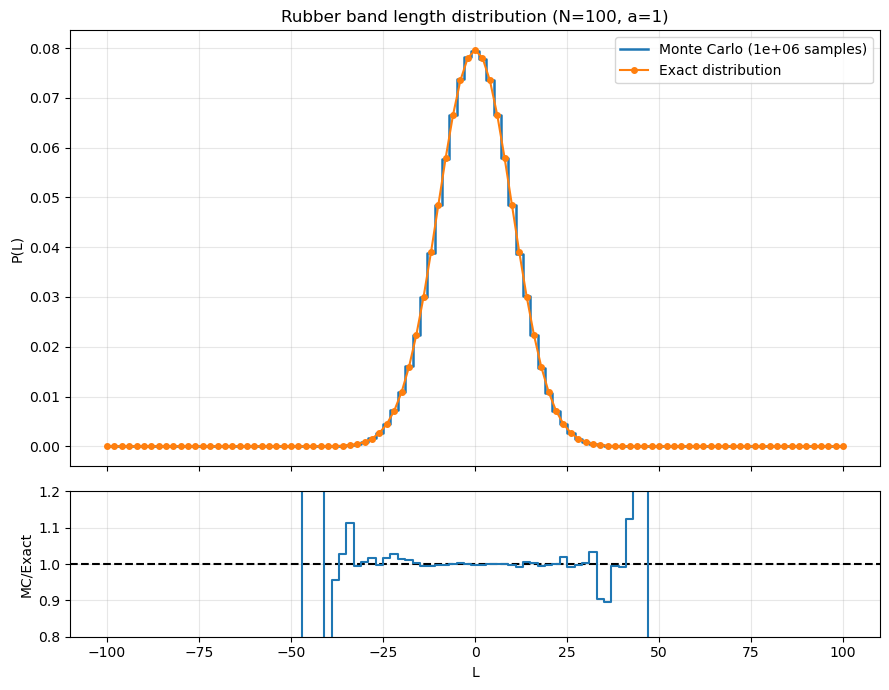

In [5]:
# Plot
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9,7),
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)

# Top: distributions
ax1.step(
    centers,
    P_mc,
    where="mid",
    linewidth=1.8,
    label=f"Monte Carlo ({M:.0e} samples)"
)

ax1.plot(
    L_vals,
    P_vals,
    marker="o",
    linestyle="-",
    markersize=4,
    label="Exact distribution"
)

ax1.set_ylabel("P(L)")
ax1.set_title(f"Rubber band length distribution (N={N}, a={a})")
ax1.legend()
ax1.grid(alpha=0.3)

# Bottom: ratio
ax2.axhline(1, color="black", linestyle="--")

ax2.step(
    centers,
    ratio,
    where="mid",
    linewidth=1.5
)

ax2.set_xlabel("L")
ax2.set_ylabel("MC/Exact")
ax2.set_ylim(0.8,1.2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

For this part, the monte carlo result is very similar to the analytic calculation, specially around L=0 as shown by the ratio comparasion graph.

### Simulation task II: pulling with a force, reweighted

In the second task we will introduce an external force (f), that will pull the rubber band in the positive direction. Here, unlike in the first task, we will do a biased simulation by using a reweighting technique. Basically, we will create unbiased microstates (just like in the first task), then compute their weights according to their Boltzmann weights, and then plot the weighted histograms. First for this, we need to extend the RubberBand class with a method that calculates the Boltzmann weight. 

f = 0.0  ->  mu_eff = 10000.0
f = 0.01  ->  mu_eff = 9900.21490601544
f = 0.03  ->  mu_eff = 9143.319584368419
f = 0.05  ->  mu_eff = 7818.381499039803
f = 0.075  ->  mu_eff = 5800.8741619603215
f = 0.1  ->  mu_eff = 3859.922532155769
f = 0.125  ->  mu_eff = 2304.1226562261077
f = 0.15  ->  mu_eff = 1232.5842904165684
f = 0.2  ->  mu_eff = 274.4666039070827
f = 0.25  ->  mu_eff = 58.75508091228269
f = 0.5  ->  mu_eff = 1.754262052311957
f = 1  ->  mu_eff = 1.0432081934605868


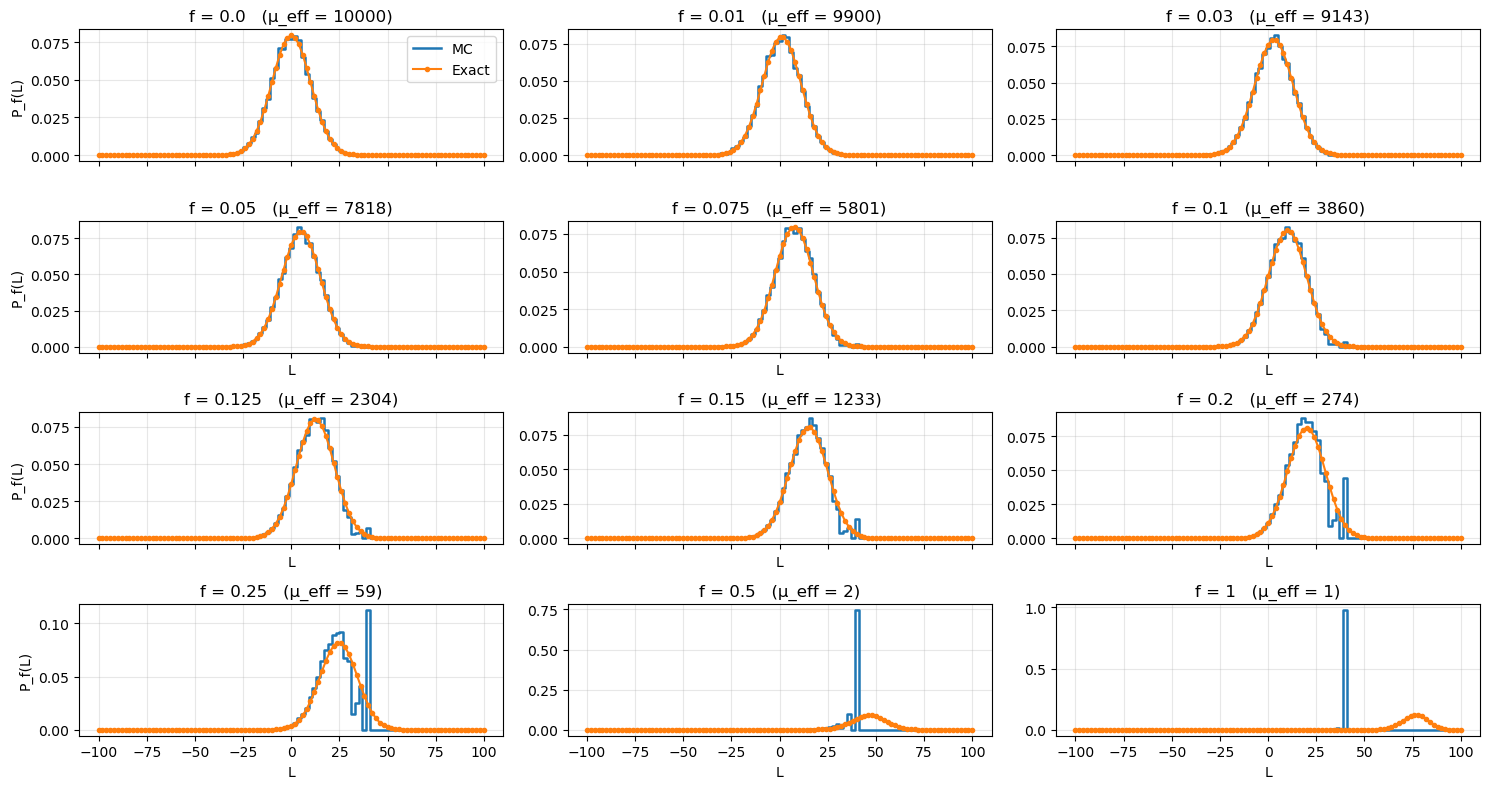

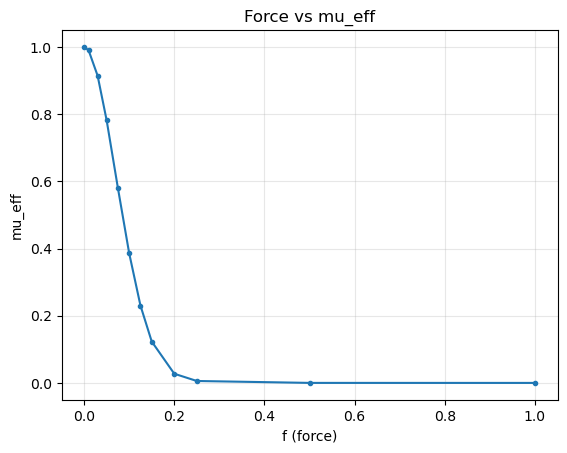

In [2]:
# Parameters
a = 1
N = 100
M = 10**4
f_vals = [0.0,0.01,0.03,0.05,0.075,0.1,0.125,0.15,0.2,0.25,0.5,1]
band = RubberBand(N=N, a=a, kBT=1)
mu_eff_vals=[]

# Allowed L values
L_vals = np.arange(-N, N + 1, 2)

# Generate ONE unbiased ensemble
L_mc = np.empty(M)
for i in range(M):
    L_mc[i] = band.sample_length_unbiased(rng)

# Histogram bins
bins = np.arange(-N - 1, N + 2, 2)

# Create subplot grid
fig, axes = plt.subplots(4, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i, f in enumerate(f_vals):

    ax = axes[i]

    # Exact distribution
    P_exact = band.P_exact_biased(L_vals, f)

    # Reweight MC samples
    w_mc = band.w_microstate(L_mc ,f)

    mu_eff = band.mu_eff(L_mc, f)
    print(f"f = {f}  ->  mu_eff = {mu_eff}")

    mu_eff_vals.append(mu_eff/M)

    # Weighted histogram
    counts, edges = np.histogram(L_mc, bins=bins, weights=w_mc)

    P_mc = counts / np.sum(counts)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Plot MC
    ax.step(
        centers,
        P_mc,
        where="mid",
        linewidth=1.8,
        label="MC"
    )

    # Plot exact
    ax.plot(
        L_vals,
        P_exact,
        marker="o",
        markersize=3,
        linestyle="-",
        label="Exact"
    )

    ax.set_title(f"f = {f}   (μ_eff = {mu_eff:.0f})")
    ax.grid(alpha=0.3)

# Axis labels (bottom)
for ax in axes[3:]:
    ax.set_xlabel("L")

for ax in axes[::3]:
    ax.set_ylabel("P_f(L)")

# Single legend
axes[0].legend()

plt.tight_layout()
plt.show()

plt.plot(f_vals, mu_eff_vals,".-")
plt.xlabel("f (force)")
plt.ylabel("mu_eff")
plt.title("Force vs mu_eff")
plt.grid(alpha=0.3)

plt.show()

Here we can see the 6 different histograms for the 6 different forces. We can see that for small forces (0.01,0.05,0.1) the theroetical curve (orange) mostly overlaps with our Monte Carlo simulation data (blue). As we start to use larger forces (0.25,0.5,1), this will not be the case anymore. If we look at the $\mu_{eff}$ values for each case, which is the number of effective samples we can see that it strongly drops for the big forces. This is because for strongly stretched samples (where f is big) long rubber bands dominate, but the unbiased sampling mostly generates small ones. So in these cases configurations with small L almost get no weight, only rare configurations with big L matter.

In the other plot we plotted the $\mu_{eff} / M$ ratio as the function of force. This ratio also shows the number of effective samples contributing to the whole simulation. We can see that it strongly drops at around 0.2, meaning that after forces bigger than that we get relatively a very small amount of effective samples.

### Simulation task III: pulling with a force, direct simulation

This task focuses on biased sampling for given values of force $f$, temperature $T$ and link length $a$. In the earlier tasks, the generated links had a 50% chance of being in either direction. Now, the link direction is decided based on the probability $p_{+}$ = $e^{\beta f a}$. The total length $L$ and average length $<L>$ are calculated across the ensemble.

When an external force $f$ is applied to the otherwise unbiased rubber band, each link present in the rubber band experiences a bias, wherein it is more likely to point in the direction of the force (+ive direction). Thus, the probability for a link to point in the positive direction is given by $p_{+}(f) = (1/2)(1+tanh(\beta f a))$

The relation between the average length( extended by force) and force is: $<L>(f) = (Na) tanh(\beta f a)$
when the force is small i.e. $\beta f a << 1$, then the relation becomes linear: $<L>(f) = (Na^2)(\beta f)$, the effective value of the spring constant K comes out as $(N \beta a^2)^{-1}$. 

When the rubber band is pulled, it is force into fewer possible configurations. The spring force is the rubber band trying to return to its original 'many configurations' state.

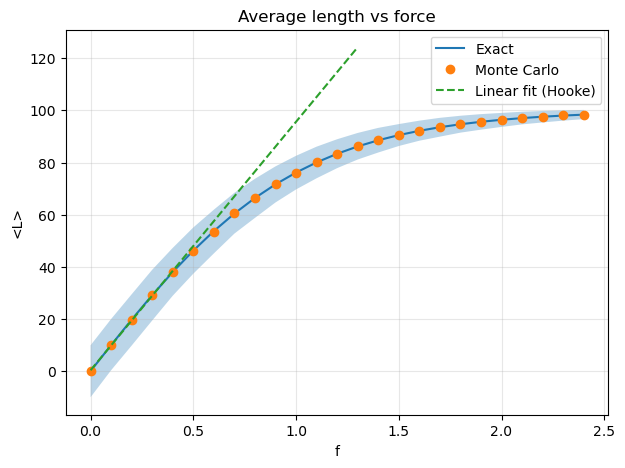

In [ ]:
# Parameters
a = 1
N = 100
M = 5000
f_vals = np.arange(0, 2.5, 0.1)

band = RubberBand(N=N, a=a, kBT=1)

L_vals = np.arange(-N, N + 1, 2)

L_mc_vals = []
L_exact = []
L_std_vals= []
for f in f_vals:

    # exact distribution
    P_exact = band.P_exact_biased(L_vals, f)

    # Monte Carlo sampling
    L_mc = np.empty(M)
    for i in range(M):
        L_mc[i] = band.sample_length_biased(rng, f)

    # averages
    avg_mc = band.avg_L(L_mc)
    avg_exact = band.avg_L_exact(L_vals, P_exact)
    std_mc = np.std(L_mc)

    L_mc_vals.append(avg_mc)
    L_exact.append(avg_exact)
    L_std_vals.append(std_mc)

# convert to arrays
L_mc_vals = np.array(L_mc_vals)
L_exact = np.array(L_exact)

coef = np.polyfit(f_vals[:5], L_mc_vals[:5], 1)
linear_fit = np.polyval(coef, f_vals[:14])

# ---------- Plot ---------------
plt.figure(figsize=(7,5))

plt.plot(f_vals, L_exact, label="Exact")
plt.plot(f_vals, L_mc_vals, "o", label="Monte Carlo")
plt.plot(f_vals[:14], linear_fit, '--', label="Linear fit (Hooke)")
plt.fill_between(
    f_vals,
    L_mc_vals - L_std_vals,
    L_mc_vals + L_std_vals,
    alpha=0.3
)
plt.xlabel("f")
plt.ylabel("<L>")
plt.title("Average length vs force")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The standard deviation area shrinks with force as an increase in the force value will coerce the band into fewer possible configurations( low entropy). The fluctuations will be less as the links are forced to stay aligned in a certain direction( represented by the +ive direction in the code). At small values of f, there are more configurations for the links to attain the specific L value and thus the standard deviation is higher.

### Simulation task IV: Nearest-neighbor corrections

This task deals with a more realistic implmentation of the model. Instead of the links being free to choose to align in either direction, they tend to be aligned with their neighbours.
This can be modeled in the code by adding the interaction term( the neighbour sum) to the earlier created Boltzmann weights. The new Boltzmann weight now becomes: $w \propto e^{\beta(f L + J \sum s_i s_{i+1})}$ where $J \sum s_i s_{i+1}$ is the interaction term between the neighbouring links.

A class CorrelatedRubberBand is derived from the RubberBand class which calculates the interaction term and the new weights. For a fixed value of $f$, a range of J values are tested and the $\mu_{eff}/M$ vs $J$ graph is plotted

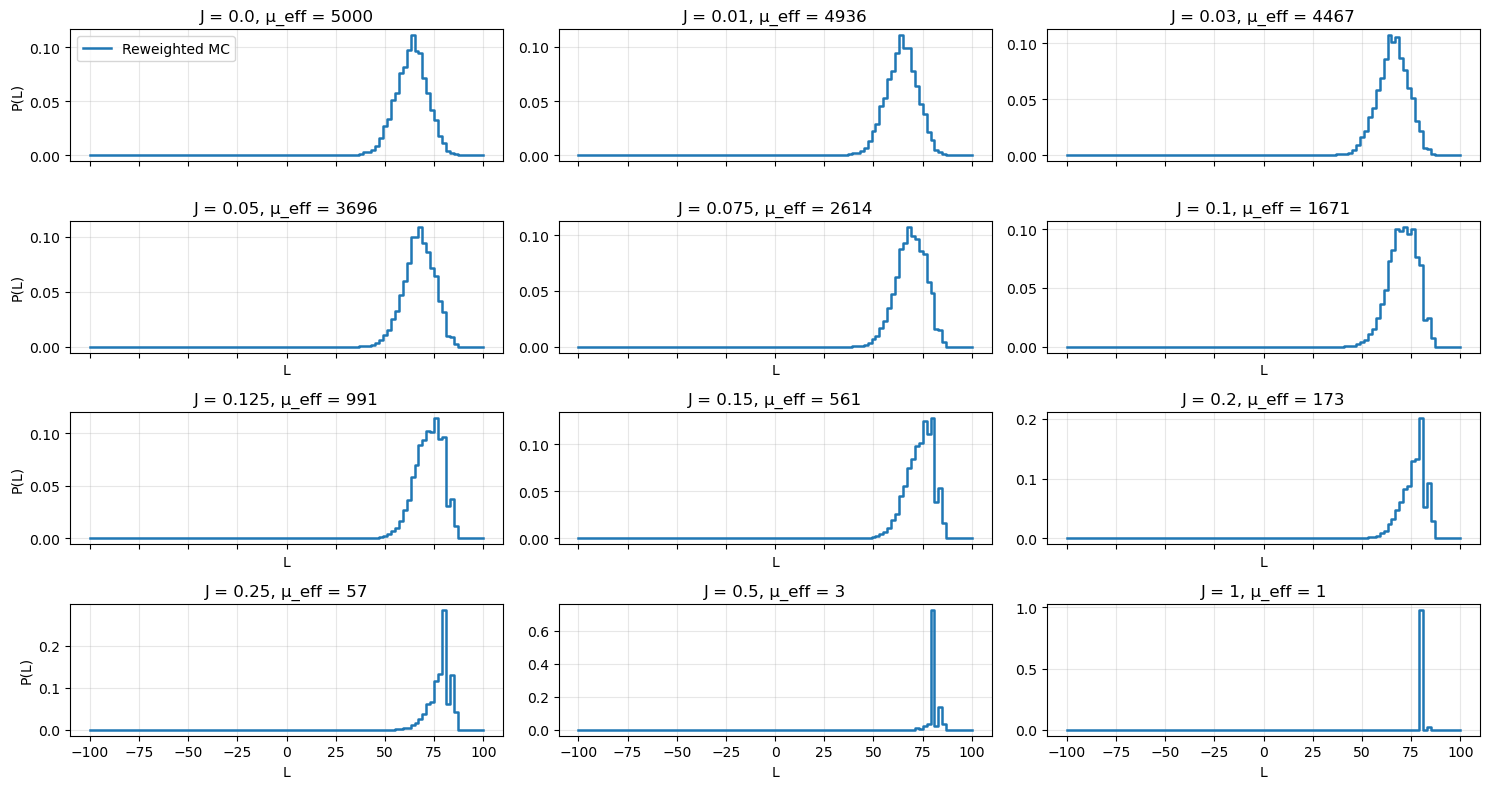

In [2]:
# Parameters
a = 1
N = 100
M = 5000
f_fixed = 0.75
J_vals = [0.0,0.01,0.03,0.05,0.075,0.1,0.125,0.15,0.2,0.25,0.5,1]

band = CorrelatedRubberBand(N=N, a=a, kBT=1)

# Generate ensemble at fixed force f
states = np.empty((M, N), dtype=int)
L_mc = np.empty(M)

for i in range(M):
    state = band.sample_microstate_biased(rng, f_fixed)
    states[i] = state
    L_mc[i] = a * np.sum(state)

bins = np.arange(-N - 1, N + 2, 2)

# ---------- Plot -----------------
fig, axes = plt.subplots(4, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i, J in enumerate(J_vals):
    ax = axes[i]

    # Reweight in J
    weights_J = band.weights_J(states, J)
    mu_eff = band.mu_eff_J(states, J)
    
    # Histogram
    counts, edges = np.histogram(L_mc, bins=bins, weights=weights_J)
    P_mc = counts / np.sum(counts)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Plot
    ax.step(centers, P_mc, where="mid", linewidth=1.8, label="Reweighted MC")
    ax.set_title(f"J = {J}, μ_eff = {mu_eff:.0f}")
    ax.grid(alpha=0.3)

for ax in axes[3:]:
    ax.set_xlabel("L")
for ax in axes[::3]:
    ax.set_ylabel("P(L)")

axes[0].legend()
plt.tight_layout()
plt.show()

It is seen that for higher values of $J$, the Monte Carlo method performs worse. Only a few rubber bands have a configuration that is likely to occur in such stiff systems.

A large value of $J$ prefers configurations where neighbouring links have the same direction. However, the Monte Carlo method generates links with random directions(also with a little bias in the later tasks), and a very stiff rubber band($J >= 0.3$) has many long aligned segments. So, the probability of generating these stiff configurations is very low and the weights have no meaning.

As an improvement, we can generate samples with a non zero $J$ value and attach the weights to them.
We can also use a Markov Chain Monte Carlo method like the Metropolis Hastings to generate the stiffness by randomly changing the link directions and integrating it into the main configuration by testing it against an acceptance probability with each iteration.

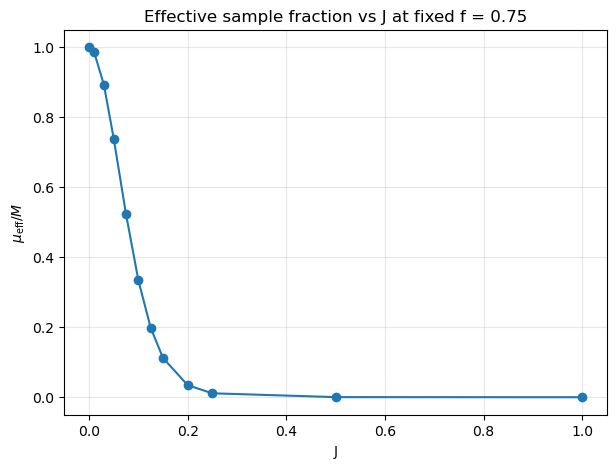

In [3]:
mu_ratios = []

for J in J_vals:
    mu_eff = band.mu_eff_J(states, J)
    mu_ratios.append(mu_eff / M)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(J_vals, mu_ratios, marker="o")
plt.xlabel("J")
plt.ylabel(r"$\mu_{\mathrm{eff}} / M$")
plt.title(f"Effective sample fraction vs J at fixed f = {f_fixed}")
plt.grid(alpha=0.3)
plt.show()